In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [5]:
#### Activar segun quien trabaje 
#Marco
Filepath = "C:/Users/asus/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
#Filepath= "C:/Users/paula/OneDrive/Documentos/10 Semestre/Tesis/base con categorias reducidas2.csv"
df=pd.read_csv(Filepath)
df

,nombre entidad,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,Otros,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,...,Presentación de oferta,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,0
1,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,1
2,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,...,Presentación de oferta,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,0
3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,...,Presentación de oferta,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,1
4,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,...,Presentación de oferta,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,Otros,Otros,Norte de Santander,Tibú,Territorial,Corporación Autónoma,Descentralizada,En ejecución,Otros,Decreto 092 de 2017,...,Presentación de oferta,1.427548e+08,Otros,Norte de Santander,Cúcuta,27.0,30.0,2023,75-100%,0
159179,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,0
159180,Otros,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,...,Presentación de oferta,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,0
159181,Otros,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,0


In [6]:
df.columns

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase', 'precio base',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'tiempo duracion (dias)', 'duracion_proceso_dias',
       'año_publicacion', 'porcentaje_pagado', 'Adicion'],
      dtype='object')

División de categoricas y númericas

In [7]:
# Seleccionar columnas categóricas, enteras y de punto flotante
catcols = df.select_dtypes(exclude=['int64', 'float64']).columns
intcols = df.select_dtypes(include=['int64']).columns
floatcols = df.select_dtypes(include=['float64']).columns



In [8]:
catcols

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'porcentaje_pagado'],
      dtype='object')

In [9]:
# Contar el número de categorías únicas por cada variable categórica
category_counts = df[catcols].nunique()

# Mostrar los resultados
print("Número de categorías por variable categórica:")
print(category_counts)

Número de categorías por variable categórica:
nombre entidad                              12
nit entidad                                 12
departamento                                18
ciudad                                     169
orden                                        3
rama                                         3
entidad centralizada                         2
estado contrato                              2
codigo de categoria principal               12
tipo de contrato                             4
modalidad de contratacion                    6
justificacion modalidad de contratacion      5
condiciones de entrega                       5
es pyme                                      2
liquidación                                  2
origen de los recursos                       2
destino gasto                                3
estado bpin                                  2
anno bpin                                    9
el contrato puede ser prorrogado             2
fase          

In [10]:
# Codificación de variables categóricas
df_dummies = pd.get_dummies(df, columns=catcols, dtype=int, drop_first=True)

# Identificar las categorías excluidas
excluded_categories = {}
for col in catcols:
    unique_values = df[col].unique()
    excluded_categories[col] = unique_values[0]  # La primera categoría es la excluida

# Mostrar las categorías excluidas
print("Categorías excluidas por multicolinealidad:")
for col, category in excluded_categories.items():
    print(f"{col}: {category}")

# Visualizar el DataFrame con variables dummies
df_dummies


Categorías excluidas por multicolinealidad:
nombre entidad: Otros
nit entidad: Otros
departamento: Meta
ciudad: Villavicencio
orden: Territorial
rama: Ejecutivo
entidad centralizada: Centralizada
estado contrato: En ejecución
codigo de categoria principal: V1.85101600
tipo de contrato: Prestación de servicios
modalidad de contratacion: Contratación régimen especial
justificacion modalidad de contratacion: Regla aplicable
condiciones de entrega: A convenir
es pyme: No
liquidación: No
origen de los recursos: Recursos Propios
destino gasto: Funcionamiento
estado bpin: No Válido
anno bpin: No D
el contrato puede ser prorrogado: No
fase: Presentación de oferta
nombre de la unidad de contratación: Otros
departamento proveedor: Meta
ciudad proveedor: Otros
porcentaje_pagado: 25-50%


,valor del contrato,valor pendiente de pago,precio base,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,Adicion,nombre entidad_ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARRENECHE,nombre entidad_FONDO FINANCIERO DISTRITAL DE SALUD.,nombre entidad_ICBF REGIONAL BOGOTA,...,ciudad proveedor_Manizales,ciudad proveedor_Medellín,ciudad proveedor_No Definido,ciudad proveedor_Otros,ciudad proveedor_Santa Marta,ciudad proveedor_Soacha,ciudad proveedor_Villavicencio,porcentaje_pagado_25-50%,porcentaje_pagado_50-75%,porcentaje_pagado_75-100%
0,8273630.0,4136815.0,8.273630e+06,38.0,39.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,5272122.0,5272122.0,2.908492e+07,48.0,53.0,2020,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8439940.0,8439940.0,5.907958e+07,50.0,57.0,2020,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34408800.0,34408800.0,3.440880e+07,88.0,90.0,2018,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,70000000.0,70000000.0,7.000000e+07,57.0,60.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,142754780.0,0.0,1.427548e+08,27.0,30.0,2023,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
159179,9000000.0,9000000.0,9.000000e+06,145.0,150.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
159180,1800000.0,1800000.0,1.800000e+06,30.0,30.0,2023,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
159181,15688277.0,15688277.0,1.568828e+07,175.0,173.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [13]:
# Definir las características (X) y la variable objetivo (y)
X = df_dummies.drop('Adicion', axis=1)  # 'Adicion' es la variable objetivo
y = df_dummies['Adicion']



In [14]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


## XGBoost

In [37]:
# Crear y entrenar el modelo XGBoost
model_XG = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=7.8,         # ajustado al desbalance
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.65
y_pred_XG_custom = (y_proba_XG >= umbral).astype(int)


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:16:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [38]:

# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom))



 Evaluación del modelo XGBoost con umbral = 0.65

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.95      0.94      0.94     28350
     Adición       0.54      0.56      0.55      3486

    accuracy                           0.90     31836
   macro avg       0.74      0.75      0.75     31836
weighted avg       0.90      0.90      0.90     31836

Matriz de confusión:
[[26684  1666]
 [ 1536  1950]]


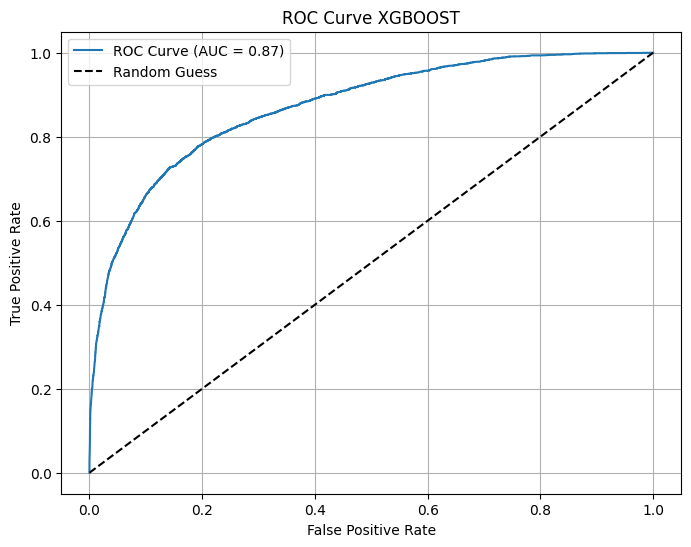

In [94]:
# Calcular las probabilidades predichas
y_pred_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_XG)

# Calcular el AUC
auc_XG = roc_auc_score(y_test, y_pred_proba_XG)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_XG:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve XGBOOST')
plt.legend()
plt.grid()
plt.show()

In [35]:
# Crear y entrenar el modelo XGBoost
model_XG = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,         # ajustado al desbalance
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XG.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.65
y_pred_XG_custom = (y_proba_XG >= umbral).astype(int)


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:15:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:

# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_custom, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_custom))




🔍 Evaluación del modelo XGBoost con umbral = 0.65

📊 Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.96      0.89      0.92     28350
     Adición       0.43      0.67      0.52      3486

    accuracy                           0.87     31836
   macro avg       0.69      0.78      0.72     31836
weighted avg       0.90      0.87      0.88     31836

🧱 Matriz de confusión:
[[25270  3080]
 [ 1154  2332]]


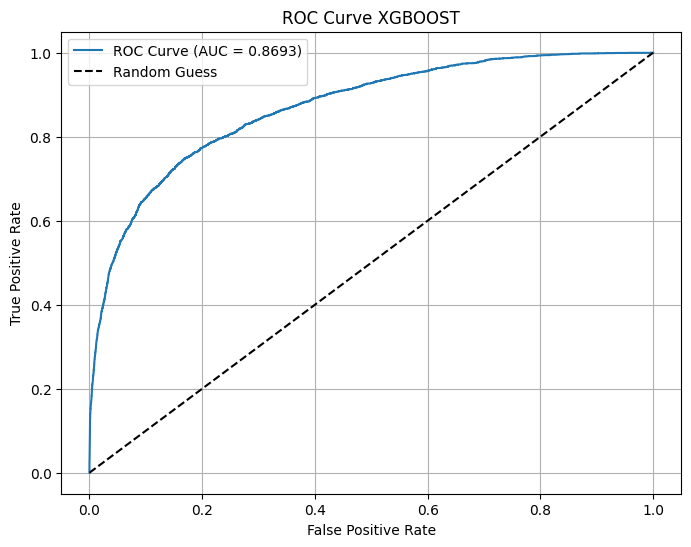

In [27]:
# Calcular las probabilidades predichas
y_pred_proba_XG = model_XG.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_XG)

# Calcular el AUC
auc_XG = roc_auc_score(y_test, y_proba_XG)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_XG:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve XGBOOST')
plt.legend()
plt.grid()
plt.show()

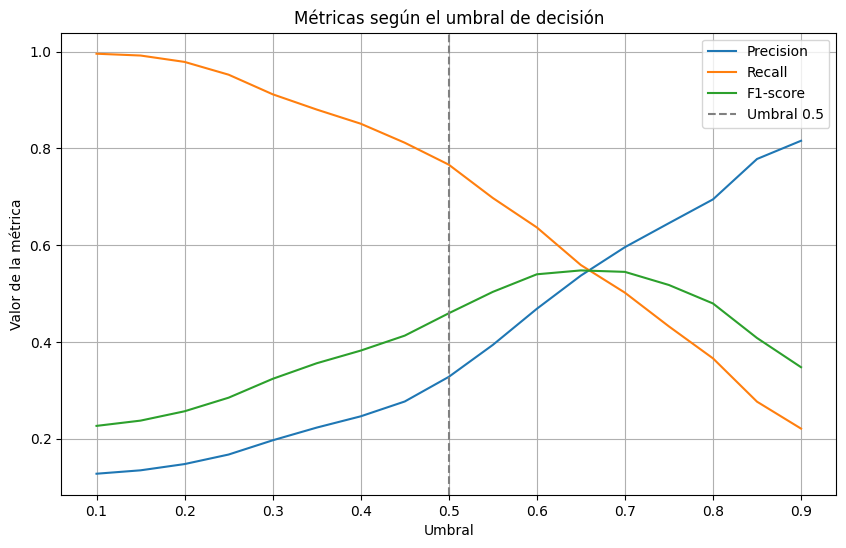

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Obtener las probabilidades predichas por el modelo
y_proba = model_XG.predict_proba(X_test)[:, 1]

# Listas para guardar resultados
umbrales = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

# Calcular métricas para cada umbral
for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)
    precisions.append(precision_score(y_test, y_pred_umbral, pos_label=1))
    recalls.append(recall_score(y_test, y_pred_umbral, pos_label=1))
    f1s.append(f1_score(y_test, y_pred_umbral, pos_label=1))

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(umbrales, precisions, label='Precision')
plt.plot(umbrales, recalls, label='Recall')
plt.plot(umbrales, f1s, label='F1-score')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Métricas según el umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
# Encontrar el umbral con mejor F1-score
mejor_idx = np.argmax(f1s)
mejor_umbral = umbrales[mejor_idx]
print(f"⭐ Mejor umbral por F1-score: {mejor_umbral:.2f}")
print(f"Precision: {precisions[mejor_idx]:.2f}, Recall: {recalls[mejor_idx]:.2f}, F1-score: {f1s[mejor_idx]:.2f}")


⭐ Mejor umbral por F1-score: 0.65
Precision: 0.54, Recall: 0.56, F1-score: 0.55


## Random Forest

In [95]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
    n_estimators=100,  # Número de árboles
    max_depth=None,    # Sin límite de profundidad
    random_state=42,   # Para reproducibilidad
    class_weight='balanced'  # Manejo de clases desbalanceadas
)

# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)



In [96]:
# Calcular métricas
print("Evaluación del modelo Randaom Forest\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_RF, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_RF = confusion_matrix(y_test, y_pred_RF)
print("\n Matriz de confusión:")
print(conf_matrix_RF)

Evaluación del modelo Randaom Forest

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.95     28350
     Adición       0.66      0.50      0.57      3486

    accuracy                           0.92     31836
   macro avg       0.80      0.73      0.76     31836
weighted avg       0.91      0.92      0.91     31836


 Matriz de confusión:
[[27473   877]
 [ 1759  1727]]


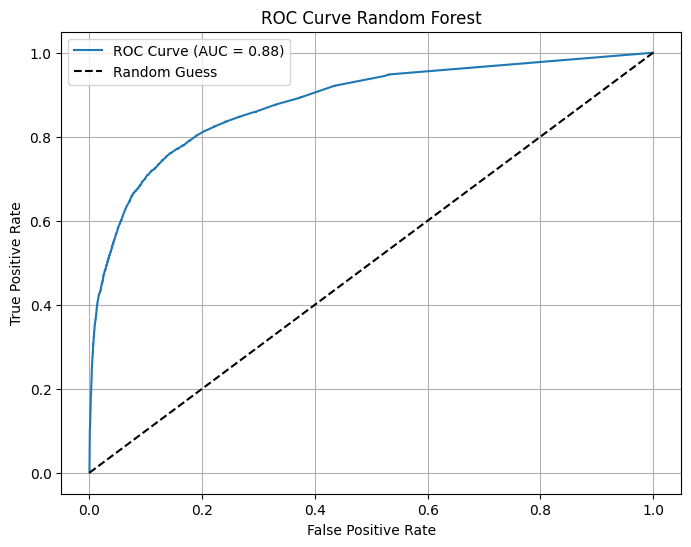

In [97]:
# Calcular las probabilidades predichas
y_pred_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_RF)

# Calcular el AUC
auc_RF = roc_auc_score(y_test, y_pred_proba_RF)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_RF:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Random Forest')
plt.legend()
plt.grid()
plt.show()

In [98]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=100,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.05,        # Tasa de aprendizaje
    subsample=0.8,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Hacer predicciones
y_pred_LGB = model_LGB.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007847 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [99]:
# Calcular métricas
print("Evaluación del modelo LightGBM\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB)
print("\n Matriz de confusión:")
print(conf_matrix_LGB)



Evaluación del modelo LightGBM

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.97      0.82      0.89     28350
     Adición       0.34      0.76      0.47      3486

    accuracy                           0.81     31836
   macro avg       0.65      0.79      0.68     31836
weighted avg       0.90      0.81      0.84     31836


 Matriz de confusión:
[[23265  5085]
 [  840  2646]]


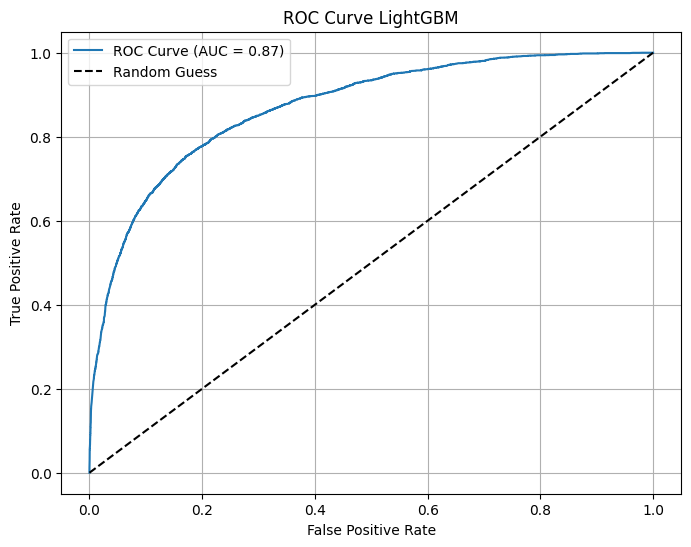

In [100]:
# Calcular las probabilidades predichas
y_pred_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_LGB)

# Calcular el AUC
auc_LGB = roc_auc_score(y_test, y_pred_proba_LGB)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_LGB:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve LightGBM')
plt.legend()
plt.grid()
plt.show()

In [101]:
# Crear y entrenar el modelo Gradient Boosting
model_GB = GradientBoostingClassifier(
    n_estimators=100,      # Número de árboles
    max_depth=8,           # Profundidad máxima de los árboles
    learning_rate=0.05,    # Tasa de aprendizaje
    subsample=0.8,         # Proporción de datos para cada árbol
    random_state=42        # Para reproducibilidad
)
# Calcular pesos de cada muestra con base en el desbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Entrenar con pesos
model_GB.fit(X_train, y_train, sample_weight=sample_weights)


# Hacer predicciones
y_pred_GB = model_GB.predict(X_test)



In [102]:
# Evaluar el modelo
print("Evaluación del modelo Gradient Boosting\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_GB, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_GB = confusion_matrix(y_test, y_pred_GB)
print("\nMatriz de confusión:")
print(conf_matrix_GB)

Evaluación del modelo Gradient Boosting

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.97      0.82      0.89     28350
     Adición       0.35      0.77      0.48      3486

    accuracy                           0.82     31836
   macro avg       0.66      0.80      0.68     31836
weighted avg       0.90      0.82      0.84     31836


Matriz de confusión:
[[23309  5041]
 [  808  2678]]


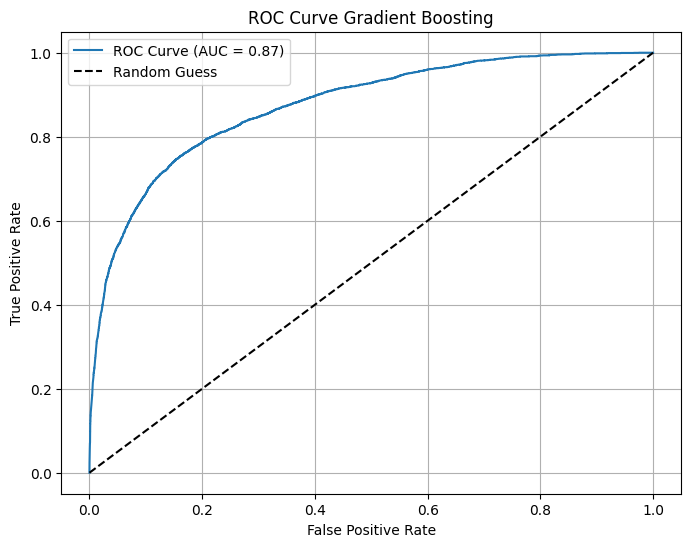

In [103]:
# Calcular las probabilidades predichas
y_pred_proba_GB = model_GB.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_GB)

# Calcular el AUC
auc_GB = roc_auc_score(y_test, y_pred_proba_GB)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_GB:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Gradient Boosting')
plt.legend()
plt.grid()
plt.show()
